# HumanLens AI — Behavior Lens

## Objective

The Behavior Lens analyzes longitudinal behavioral trends and converts
them into structured contextual features for the HumanLens AI system.

The purpose is not to diagnose, classify, or infer a person's medical
or psychological condition.

Instead, the system identifies observable trends in user-provided
behavioral/contextual variables.

## Behavioral Variables

The initial research prototype considers:

- Sleep duration
- Stress level
- Academic pressure
- Social interaction
- Screen time
- Mood
- Physical activity

## Research Questions

1. Can behavioral variables be normalized into comparable features?
2. Can longitudinal changes be represented as trends?
3. Can multiple behavioral signals be combined into an interpretable
   contextual score?
4. Can structured behavioral context improve downstream HumanLens
   reasoning without making diagnostic claims?

## Design Principle

The Behavior Lens should describe changes and patterns rather than
assigning psychological or medical labels.

For example:

"Sleep decreased over the last 7 days and reported stress increased."

is preferable to:

"The user is clinically stressed."

## Privacy Principle

The prototype uses synthetic research data.

In a real deployment, behavioral data should be collected only with
appropriate user consent and processed according to the project's
privacy requirements.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
np.random.seed(42)

days = pd.date_range(
    start="2026-01-01",
    periods=30,
    freq="D"
)

behavior_df = pd.DataFrame({
    "date": days,

    "sleep_hours": np.clip(
        np.random.normal(6.5, 1.0, 30),
        3.5,
        9
    ),

    "stress_level": np.clip(
        np.random.normal(5.5, 2.0, 30),
        0,
        10
    ),

    "academic_pressure": np.clip(
        np.random.normal(5.5, 2.0, 30),
        0,
        10
    ),

    "social_interaction_hours": np.clip(
        np.random.normal(2.5, 1.2, 30),
        0,
        8
    ),

    "screen_time_hours": np.clip(
        np.random.normal(6, 1.8, 30),
        1,
        12
    ),

    "mood_score": np.clip(
        np.random.normal(5.5, 2.0, 30),
        0,
        10
    ),

    "physical_activity_minutes": np.clip(
        np.random.normal(40, 20, 30),
        0,
        120
    )
})

print("Synthetic longitudinal behavioral dataset created.")
print("Shape:", behavior_df.shape)

display(behavior_df.head())

Synthetic longitudinal behavioral dataset created.
Shape: (30, 8)


,date,sleep_hours,stress_level,academic_pressure,social_interaction_hours,screen_time_hours,mood_score,physical_activity_minutes
0,2026-01-01,6.996714,4.296587,4.541652,2.616493,7.423858,6.000986,52.513347
1,2026-01-02,6.361736,9.204556,5.128682,3.662374,4.363103,6.192896,22.856849
2,2026-01-03,7.147689,5.473006,3.287330,1.657536,8.525030,4.139951,18.582150
3,2026-01-04,8.023030,3.384578,3.107587,2.106805,3.476668,5.964507,49.649448
4,2026-01-05,6.265847,7.145090,7.125052,2.029470,7.056343,6.086145,35.530744


In [3]:
np.random.seed(42)

days = pd.date_range(
    start="2026-01-01",
    periods=30,
    freq="D"
)

behavior_df = pd.DataFrame({
    "date": days,

    "sleep_hours": np.clip(
        np.random.normal(6.5, 1.0, 30),
        3.5,
        9
    ),

    "stress_level": np.clip(
        np.random.normal(5.5, 2.0, 30),
        0,
        10
    ),

    "academic_pressure": np.clip(
        np.random.normal(5.5, 2.0, 30),
        0,
        10
    ),

    "social_interaction_hours": np.clip(
        np.random.normal(2.5, 1.2, 30),
        0,
        8
    ),

    "screen_time_hours": np.clip(
        np.random.normal(6, 1.8, 30),
        1,
        12
    ),

    "mood_score": np.clip(
        np.random.normal(5.5, 2.0, 30),
        0,
        10
    ),

    "physical_activity_minutes": np.clip(
        np.random.normal(40, 20, 30),
        0,
        120
    )
})

print("Synthetic longitudinal behavioral dataset created.")
print("Shape:", behavior_df.shape)

display(behavior_df.head())

Synthetic longitudinal behavioral dataset created.
Shape: (30, 8)


,date,sleep_hours,stress_level,academic_pressure,social_interaction_hours,screen_time_hours,mood_score,physical_activity_minutes
0,2026-01-01,6.996714,4.296587,4.541652,2.616493,7.423858,6.000986,52.513347
1,2026-01-02,6.361736,9.204556,5.128682,3.662374,4.363103,6.192896,22.856849
2,2026-01-03,7.147689,5.473006,3.287330,1.657536,8.525030,4.139951,18.582150
3,2026-01-04,8.023030,3.384578,3.107587,2.106805,3.476668,5.964507,49.649448
4,2026-01-05,6.265847,7.145090,7.125052,2.029470,7.056343,6.086145,35.530744


In [4]:
print("Dataset information")
print("=" * 50)

print(behavior_df.info())

Dataset information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date                       30 non-null     datetime64[ns]
 1   sleep_hours                30 non-null     float64       
 2   stress_level               30 non-null     float64       
 3   academic_pressure          30 non-null     float64       
 4   social_interaction_hours   30 non-null     float64       
 5   screen_time_hours          30 non-null     float64       
 6   mood_score                 30 non-null     float64       
 7   physical_activity_minutes  30 non-null     float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 2.0 KB
None


In [5]:
print("\nMissing values:")
print(behavior_df.isnull().sum())


Missing values:
date                         0
sleep_hours                  0
stress_level                 0
academic_pressure            0
social_interaction_hours     0
screen_time_hours            0
mood_score                   0
physical_activity_minutes    0
dtype: int64


In [6]:
print("\nSummary statistics:")
display(behavior_df.describe())


Summary statistics:


,date,sleep_hours,stress_level,academic_pressure,social_interaction_hours,screen_time_hours,mood_score,physical_activity_minutes
count,30,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,2026-01-15 12:00:00,6.311853,5.257675,5.525770,2.475698,5.829075,6.026229,41.311846
min,2026-01-01 00:00:00,4.586720,1.580660,0.260510,0.197475,3.106530,3.117393,9.703056
25%,2026-01-08 06:00:00,5.908949,4.081773,4.471716,2.044288,4.249035,4.347635,22.908668
50%,2026-01-15 12:00:00,6.265855,5.370854,5.551221,2.463265,6.151393,6.069763,43.872747
75%,2026-01-22 18:00:00,6.860335,6.589324,6.975422,2.844825,7.027131,7.126633,50.300892
max,2026-01-30 00:00:00,8.079213,9.204556,8.629287,5.455891,9.942820,10.000000,117.054630
std,NaN,0.900006,1.862204,1.983966,1.090586,1.843489,1.817369,21.055789


In [7]:
from sklearn.preprocessing import MinMaxScaler

behavior_features = [
    "sleep_hours",
    "stress_level",
    "academic_pressure",
    "social_interaction_hours",
    "screen_time_hours",
    "mood_score",
    "physical_activity_minutes"
]

scaler = MinMaxScaler()

behavior_normalized = scaler.fit_transform(
    behavior_df[behavior_features]
)

normalized_df = pd.DataFrame(
    behavior_normalized,
    columns=behavior_features
)

print("Behavioral variables normalized to [0, 1].")

display(normalized_df.head())

Behavioral variables normalized to [0, 1].


,sleep_hours,stress_level,academic_pressure,social_interaction_hours,screen_time_hours,mood_score,physical_activity_minutes
0,0.690050,0.356239,0.511561,0.460028,0.631531,0.418968,0.398786
1,0.508238,1.000000,0.581706,0.658925,0.183809,0.446852,0.122530
2,0.733278,0.510545,0.361680,0.277662,0.792608,0.148571,0.082710
3,0.983913,0.236614,0.340202,0.363100,0.054143,0.413668,0.372108
4,0.480782,0.729867,0.820256,0.348393,0.577771,0.431341,0.240590


In [8]:
for feature in behavior_features:

    behavior_df[
        feature + "_normalized"
    ] = normalized_df[feature]

print("Normalized features added successfully.")

Normalized features added successfully.


In [9]:
behavior_df.head()

,date,sleep_hours,stress_level,academic_pressure,social_interaction_hours,screen_time_hours,mood_score,physical_activity_minutes,sleep_hours_normalized,stress_level_normalized,academic_pressure_normalized,social_interaction_hours_normalized,screen_time_hours_normalized,mood_score_normalized,physical_activity_minutes_normalized
0,2026-01-01,6.996714,4.296587,4.541652,2.616493,7.423858,6.000986,52.513347,0.690050,0.356239,0.511561,0.460028,0.631531,0.418968,0.398786
1,2026-01-02,6.361736,9.204556,5.128682,3.662374,4.363103,6.192896,22.856849,0.508238,1.000000,0.581706,0.658925,0.183809,0.446852,0.122530
2,2026-01-03,7.147689,5.473006,3.287330,1.657536,8.525030,4.139951,18.582150,0.733278,0.510545,0.361680,0.277662,0.792608,0.148571,0.082710
3,2026-01-04,8.023030,3.384578,3.107587,2.106805,3.476668,5.964507,49.649448,0.983913,0.236614,0.340202,0.363100,0.054143,0.413668,0.372108
4,2026-01-05,6.265847,7.145090,7.125052,2.029470,7.056343,6.086145,35.530744,0.480782,0.729867,0.820256,0.348393,0.577771,0.431341,0.240590


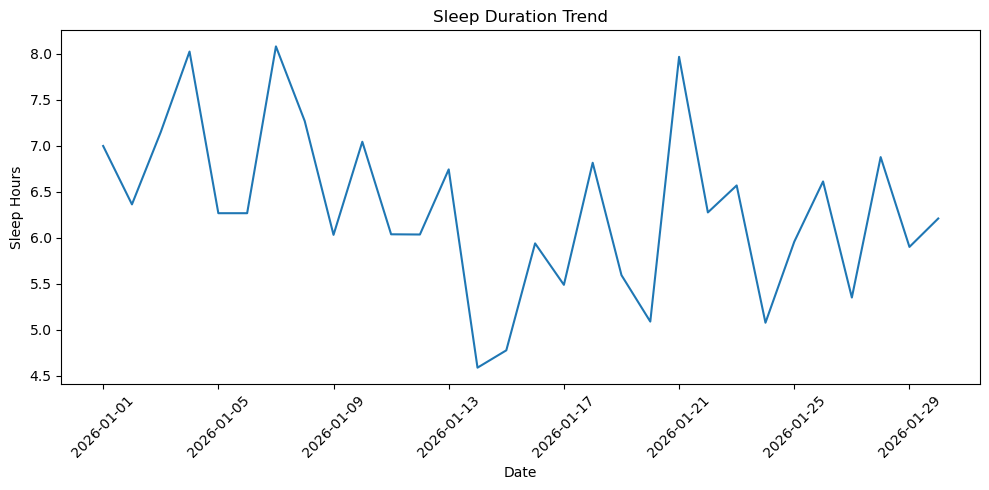

In [10]:
plt.figure(figsize=(10, 5))

plt.plot(
    behavior_df["date"],
    behavior_df["sleep_hours"]
)

plt.title("Sleep Duration Trend")
plt.xlabel("Date")
plt.ylabel("Sleep Hours")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

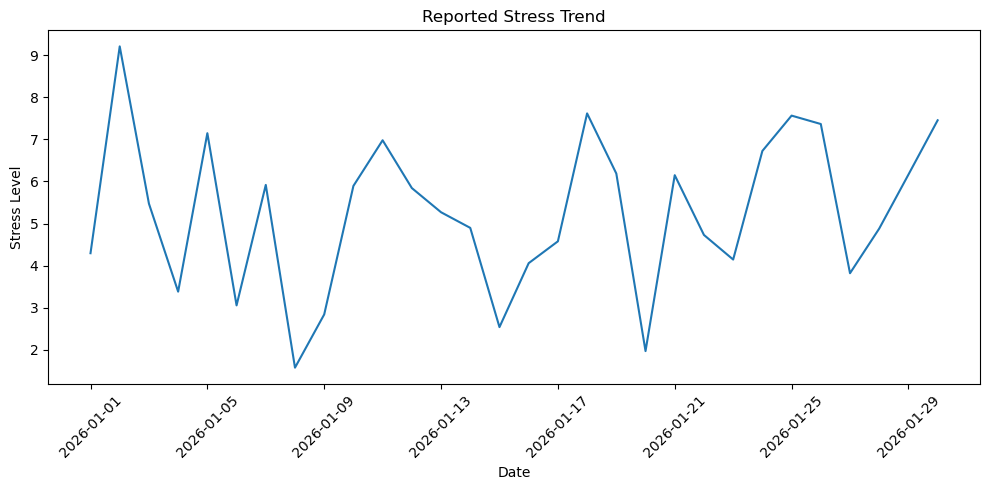

In [11]:
plt.figure(figsize=(10, 5))

plt.plot(
    behavior_df["date"],
    behavior_df["stress_level"]
)

plt.title("Reported Stress Trend")
plt.xlabel("Date")
plt.ylabel("Stress Level")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

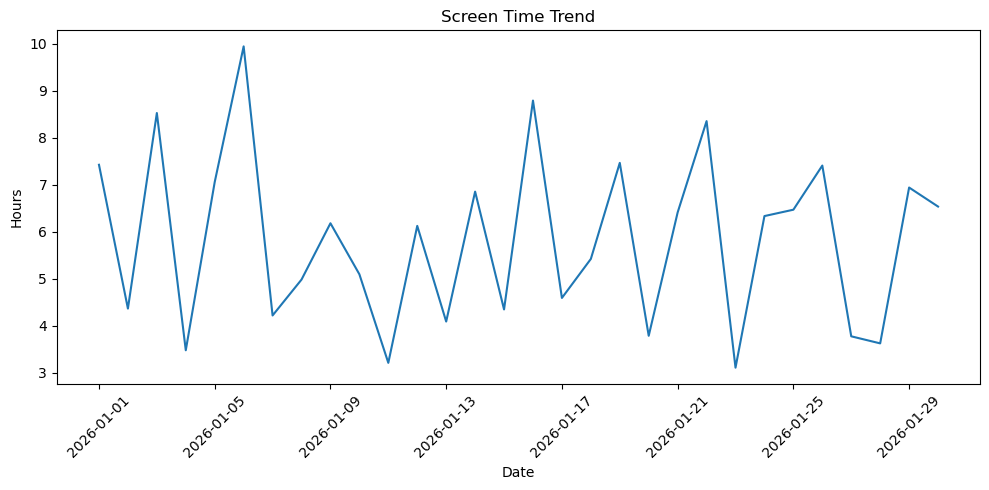

In [12]:
plt.figure(figsize=(10, 5))

plt.plot(
    behavior_df["date"],
    behavior_df["screen_time_hours"]
)

plt.title("Screen Time Trend")
plt.xlabel("Date")
plt.ylabel("Hours")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [13]:
trend_features = [
    "sleep_hours",
    "stress_level",
    "academic_pressure",
    "social_interaction_hours",
    "screen_time_hours",
    "mood_score",
    "physical_activity_minutes"
]

for feature in trend_features:

    behavior_df[
        feature + "_7d_avg"
    ] = (
        behavior_df[feature]
        .rolling(window=7, min_periods=1)
        .mean()
    )

print("7-day behavioral trends calculated.")

7-day behavioral trends calculated.


In [14]:
for feature in trend_features:

    behavior_df[
        feature + "_change"
    ] = (
        behavior_df[feature]
        - behavior_df[feature].shift(7)
    )

print("Weekly behavioral changes calculated.")

Weekly behavioral changes calculated.


In [15]:
recent_columns = [
    "date",
    "sleep_hours_change",
    "stress_level_change",
    "academic_pressure_change",
    "social_interaction_hours_change",
    "screen_time_hours_change",
    "mood_score_change",
    "physical_activity_minutes_change"
]

display(
    behavior_df[recent_columns].tail(10)
)

,date,sleep_hours_change,stress_level_change,academic_pressure_change,social_interaction_hours_change,screen_time_hours_change,mood_score_change,physical_activity_minutes_change
20,2026-01-21,3.378929,1.250375,-3.568631,-1.339793,-0.443038,-0.137664,32.070523
21,2026-01-22,1.499142,2.186879,5.953715,0.161726,4.007821,-3.558373,7.752072
22,2026-01-23,0.629816,0.085844,1.311983,-0.412585,-5.683352,-0.979765,13.954677
23,2026-01-24,-0.411917,2.144630,-1.210635,0.692467,1.742197,-0.961816,38.753190
24,2026-01-25,-0.858630,-0.052245,-1.018973,-0.440327,1.047500,-3.240204,-30.627889
25,2026-01-26,1.018947,1.175324,-1.187036,0.052796,-0.057050,2.145143,-19.920675
26,2026-01-27,0.261310,1.847645,5.805942,0.047681,-0.010956,1.533476,33.160111
27,2026-01-28,-1.089951,-1.266593,1.096846,0.900112,-2.786250,4.686097,3.119972
28,2026-01-29,-0.374862,1.432691,-1.773746,1.403204,-1.413362,1.102307,-0.914737
29,2026-01-30,-0.359222,3.304934,-1.929253,0.830043,3.428042,4.654203,55.393605


In [16]:
def trend_direction(change):

    if pd.isna(change):
        return "Insufficient history"

    if change > 0.10:
        return "Increasing"

    elif change < -0.10:
        return "Decreasing"

    else:
        return "Stable"

In [17]:
trend_variables = [
    "sleep_hours",
    "stress_level",
    "academic_pressure",
    "social_interaction_hours",
    "screen_time_hours",
    "mood_score",
    "physical_activity_minutes"
]

for feature in trend_variables:

    behavior_df[
        feature + "_trend"
    ] = behavior_df[
        feature + "_change"
    ].apply(trend_direction)

print("Trend indicators created.")

Trend indicators created.


In [18]:
latest = behavior_df.iloc[-1]

behavior_context = {
    "sleep": {
        "current_hours": round(
            latest["sleep_hours"], 2
        ),
        "trend": latest["sleep_hours_trend"]
    },

    "stress": {
        "current_level": round(
            latest["stress_level"], 2
        ),
        "trend": latest["stress_level_trend"]
    },

    "academic_pressure": {
        "current_level": round(
            latest["academic_pressure"], 2
        ),
        "trend": latest["academic_pressure_trend"]
    },

    "social_interaction": {
        "current_hours": round(
            latest["social_interaction_hours"], 2
        ),
        "trend": latest["social_interaction_hours_trend"]
    },

    "screen_time": {
        "current_hours": round(
            latest["screen_time_hours"], 2
        ),
        "trend": latest["screen_time_hours_trend"]
    },

    "mood": {
        "current_score": round(
            latest["mood_score"], 2
        ),
        "trend": latest["mood_score_trend"]
    },

    "physical_activity": {
        "current_minutes": round(
            latest["physical_activity_minutes"], 2
        ),
        "trend": latest["physical_activity_minutes_trend"]
    }
}

behavior_context

{'sleep': {'current_hours': np.float64(6.21), 'trend': 'Decreasing'},
 'stress': {'current_level': np.float64(7.45), 'trend': 'Increasing'},
 'academic_pressure': {'current_level': np.float64(6.53),
  'trend': 'Decreasing'},
 'social_interaction': {'current_hours': np.float64(3.4),
  'trend': 'Increasing'},
 'screen_time': {'current_hours': np.float64(6.53), 'trend': 'Increasing'},
 'mood': {'current_score': np.float64(10.0), 'trend': 'Increasing'},
 'physical_activity': {'current_minutes': np.float64(117.05),
  'trend': 'Increasing'}}

In [19]:
context_components = pd.DataFrame({

    "sleep_change": behavior_df[
        "sleep_hours_change"
    ].abs(),

    "stress_change": behavior_df[
        "stress_level_change"
    ].abs(),

    "academic_change": behavior_df[
        "academic_pressure_change"
    ].abs(),

    "social_change": behavior_df[
        "social_interaction_hours_change"
    ].abs(),

    "screen_change": behavior_df[
        "screen_time_hours_change"
    ].abs(),

    "mood_change": behavior_df[
        "mood_score_change"
    ].abs(),

    "activity_change": behavior_df[
        "physical_activity_minutes_change"
    ].abs()
})

context_components = context_components.fillna(0)

In [20]:
context_scaler = MinMaxScaler()

context_normalized = context_scaler.fit_transform(
    context_components
)

context_normalized_df = pd.DataFrame(
    context_normalized,
    columns=context_components.columns
)

In [21]:
behavior_df["behavioral_change_score"] = (
    context_normalized_df.mean(axis=1)
)

print(
    behavior_df[
        [
            "date",
            "behavioral_change_score"
        ]
    ].tail(10)
)

         date  behavioral_change_score
20 2026-01-21                 0.408795
21 2026-01-22                 0.443179
22 2026-01-23                 0.275744
23 2026-01-24                 0.294128
24 2026-01-25                 0.266247
25 2026-01-26                 0.200567
26 2026-01-27                 0.293249
27 2026-01-28                 0.337776
28 2026-01-29                 0.225509
29 2026-01-30                 0.515818


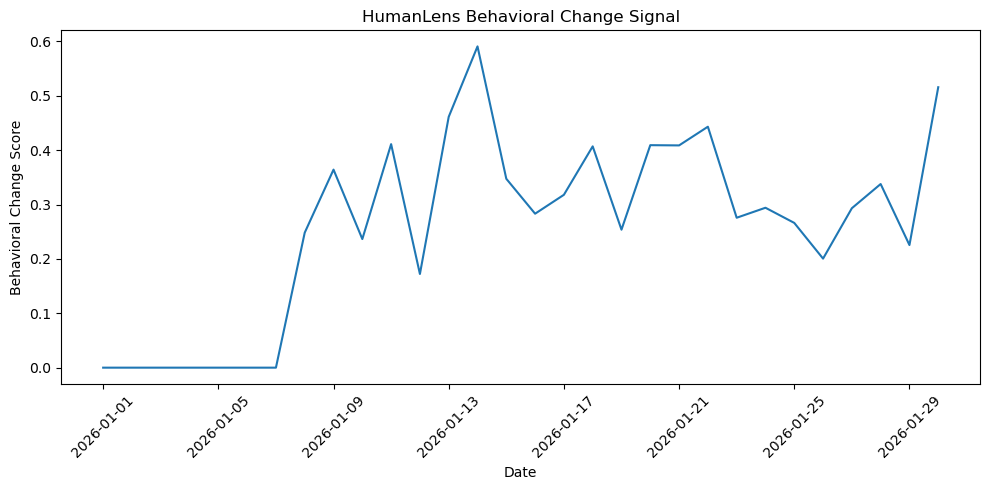

In [22]:
plt.figure(figsize=(10, 5))

plt.plot(
    behavior_df["date"],
    behavior_df["behavioral_change_score"]
)

plt.title("HumanLens Behavioral Change Signal")
plt.xlabel("Date")
plt.ylabel("Behavioral Change Score")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [23]:
def generate_behavior_summary(df):

    latest = df.iloc[-1]

    summary = []

    summary.append(
        f"Sleep is currently "
        f"{latest['sleep_hours']:.1f} hours, with a "
        f"{latest['sleep_hours_trend'].lower()} trend."
    )

    summary.append(
        f"Reported stress is "
        f"{latest['stress_level']:.1f}/10, with an "
        f"{latest['stress_level_trend'].lower()} trend."
    )

    summary.append(
        f"Academic pressure is "
        f"{latest['academic_pressure']:.1f}/10, with an "
        f"{latest['academic_pressure_trend'].lower()} trend."
    )

    summary.append(
        f"Screen time is "
        f"{latest['screen_time_hours']:.1f} hours, with an "
        f"{latest['screen_time_hours_trend'].lower()} trend."
    )

    return " ".join(summary)


behavior_summary = generate_behavior_summary(
    behavior_df
)

print(behavior_summary)

Sleep is currently 6.2 hours, with a decreasing trend. Reported stress is 7.5/10, with an increasing trend. Academic pressure is 6.5/10, with an decreasing trend. Screen time is 6.5 hours, with an increasing trend.


In [24]:
processed_dir = Path("../data/processed")

processed_dir.mkdir(
    parents=True,
    exist_ok=True
)

behavior_path = (
    processed_dir /
    "behavior_lens_synthetic.csv"
)

behavior_df.to_csv(
    behavior_path,
    index=False,
    encoding="utf-8-sig"
)

print("Behavior dataset saved successfully.")
print(behavior_path)

Behavior dataset saved successfully.
..\data\processed\behavior_lens_synthetic.csv


In [25]:
import json

results_dir = Path("../results")

results_dir.mkdir(
    parents=True,
    exist_ok=True
)

context_path = (
    results_dir /
    "behavior_context.json"
)

with open(
    context_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        behavior_context,
        file,
        indent=4
    )

print("Behavior context saved successfully.")
print(context_path)

Behavior context saved successfully.
..\results\behavior_context.json


# Behavior Lens — Research Findings

## Objective

The Behavior Lens was designed to represent longitudinal behavioral
patterns as structured contextual information.

## Behavioral Variables

The prototype considered:

- Sleep duration
- Stress level
- Academic pressure
- Social interaction
- Screen time
- Mood
- Physical activity

## Method

The behavioral variables were:

1. Normalized to comparable scales.
2. Analyzed using rolling seven-day averages.
3. Compared with previous-week values.
4. Converted into directional trend indicators.
5. Combined into an interpretable behavioral-change signal.

## Behavioral Context

The system generates structured context containing current values and
trend directions.

This representation is intended for downstream AI reasoning.

## Safety Limitation

The Behavior Lens does not diagnose mental-health conditions and does
not determine a user's psychological state.

A behavioral change score represents the magnitude of measured changes
within the available behavioral data.

It should not be interpreted as clinical risk.

## Data Limitation

The current prototype uses synthetic longitudinal data.

Future research should evaluate the methodology using appropriately
consented and anonymized real-world data.

## HumanLens Integration

The Behavior Lens will eventually provide contextual information to the
HumanLens Multimodal Fusion Engine alongside:

- Text toxicity
- Text aggression
- Text emotion
- Voice features
- Facial-expression features

## Next Stage

The next stage is voice-feature extraction and analysis.